In [1]:
"""
Unseen Region 1
--> MOO search (high activity pred only)
    -->  zero-shot filter
"""
import json
import os
import logging
import numpy as np
import requests
from PIL import Image
import scipy.stats
import matplotlib.pyplot as plt
import sys
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

# pandas
import pandas as pd
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)


import importlib
sys.path.append('/nfs_beijing/yujie/toolset/')

# tools
from model_for_data.common_tools.hash_util import hash_list
from task_tools.filter.ptm_rules import PTMFilter

# check环境
print(sys.executable)
print(sys.version)

/nfs_beijing/kubeflow-user/yujie/.conda/envs/icey/bin/python
3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]


In [2]:
def lib_mutation_distribution(df, title, density=True, exlist=[]):
    out = {}
    for mut in df['pdb_mutation'].to_list():
        if mut == '':
            continue
        mut = mut.split(',')

        for m in mut:
            if m in exlist:
                continue
            posi = int(m[2:-1])
            if posi not in out:
                out[posi] = {}
            if m[-1] not in out[posi]:
                out[posi][m[-1]] = 0
            out[posi][m[-1]] += 1
    # 创建热力图
    mut_df = pd.DataFrame(out).sort_index().fillna(0).T
    if density:
        mut_df = mut_df.div(mut_df.sum(axis=1), axis=0)
    mut_df = mut_df.sort_index()
    fig, ax = plt.subplots(figsize=(10, 10 * (mut_df.shape[0] / mut_df.shape[1])), dpi=200)
    im = ax.imshow(mut_df, cmap='YlOrRd')

    # 添加颜色条
    cbar = ax.figure.colorbar(im, ax=ax)
    # 添加标题和坐标轴标签
    ax.set_title(f'Distribution of mutations: {title}')
    ax.set_ylabel('Amino Acid Position')
    ax.set_xlabel('Amino Acid')

    # 设置坐标轴刻度标签
    ax.set_xticks(np.arange(len(mut_df.columns)))
    ax.set_yticks(np.arange(len(mut_df.index)))
    ax.set_xticklabels(mut_df.columns)
    ax.set_yticklabels(mut_df.index)
    # 显示图形
    plt.show()

In [32]:
data = pd.read_csv('../data/data_ai_r3_moo_optimal_unseen_region_high_ac.csv')

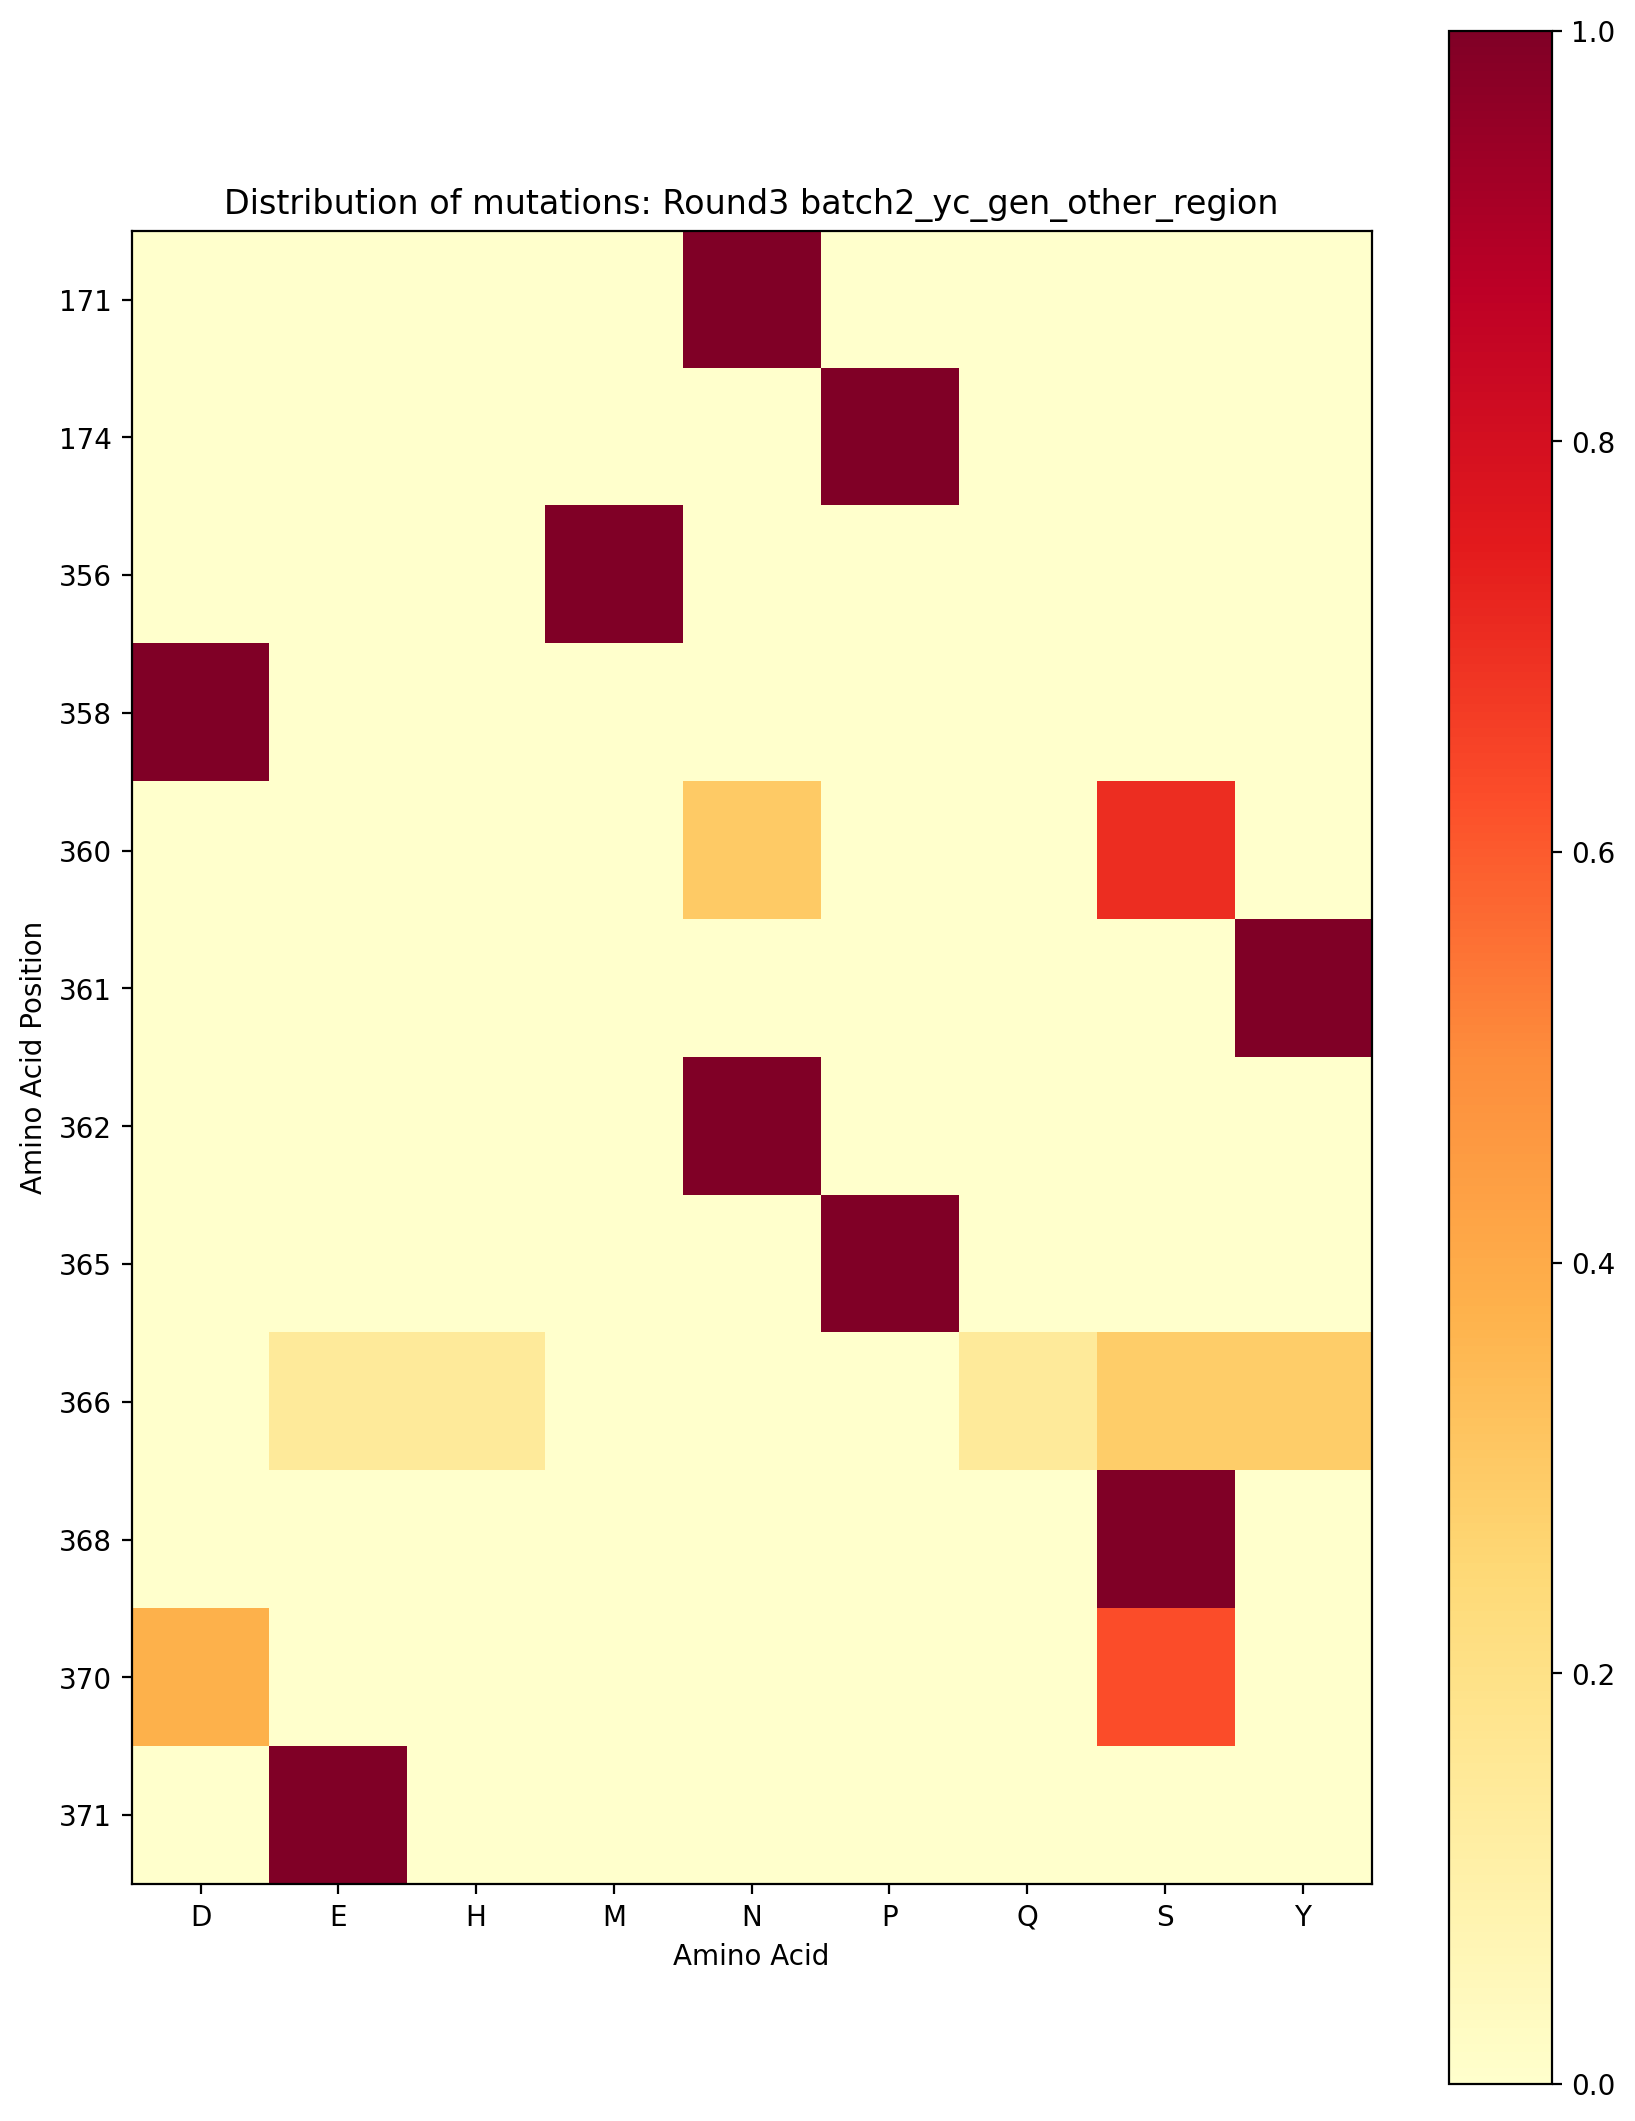

In [33]:
lib_mutation_distribution(data_filtered3, title='Round3 batch2_yc_gen_other_region')

In [34]:
# 沿用之前的阈值，简化逻辑，避免额外的人工干预
filter_config = {
    'sequence_naturalness': 'sequence_naturalness < 3.6', 
    'stability': 'stability > -0.4',
    'structure_naturalness': 'structure_naturalness > -10.32',
}
# 联合过滤漏斗
data_filtered3 = data.copy(deep=True)
for score, query in filter_config.items():
    data_filtered3 = data_filtered3.query(query)
    print(score, query, data_filtered3.shape[0], round(data_filtered3.shape[0]/data.shape[0], 3))

sequence_naturalness sequence_naturalness < 3.6 51 1.0
stability stability > -0.4 51 1.0
structure_naturalness structure_naturalness > -10.32 10 0.196


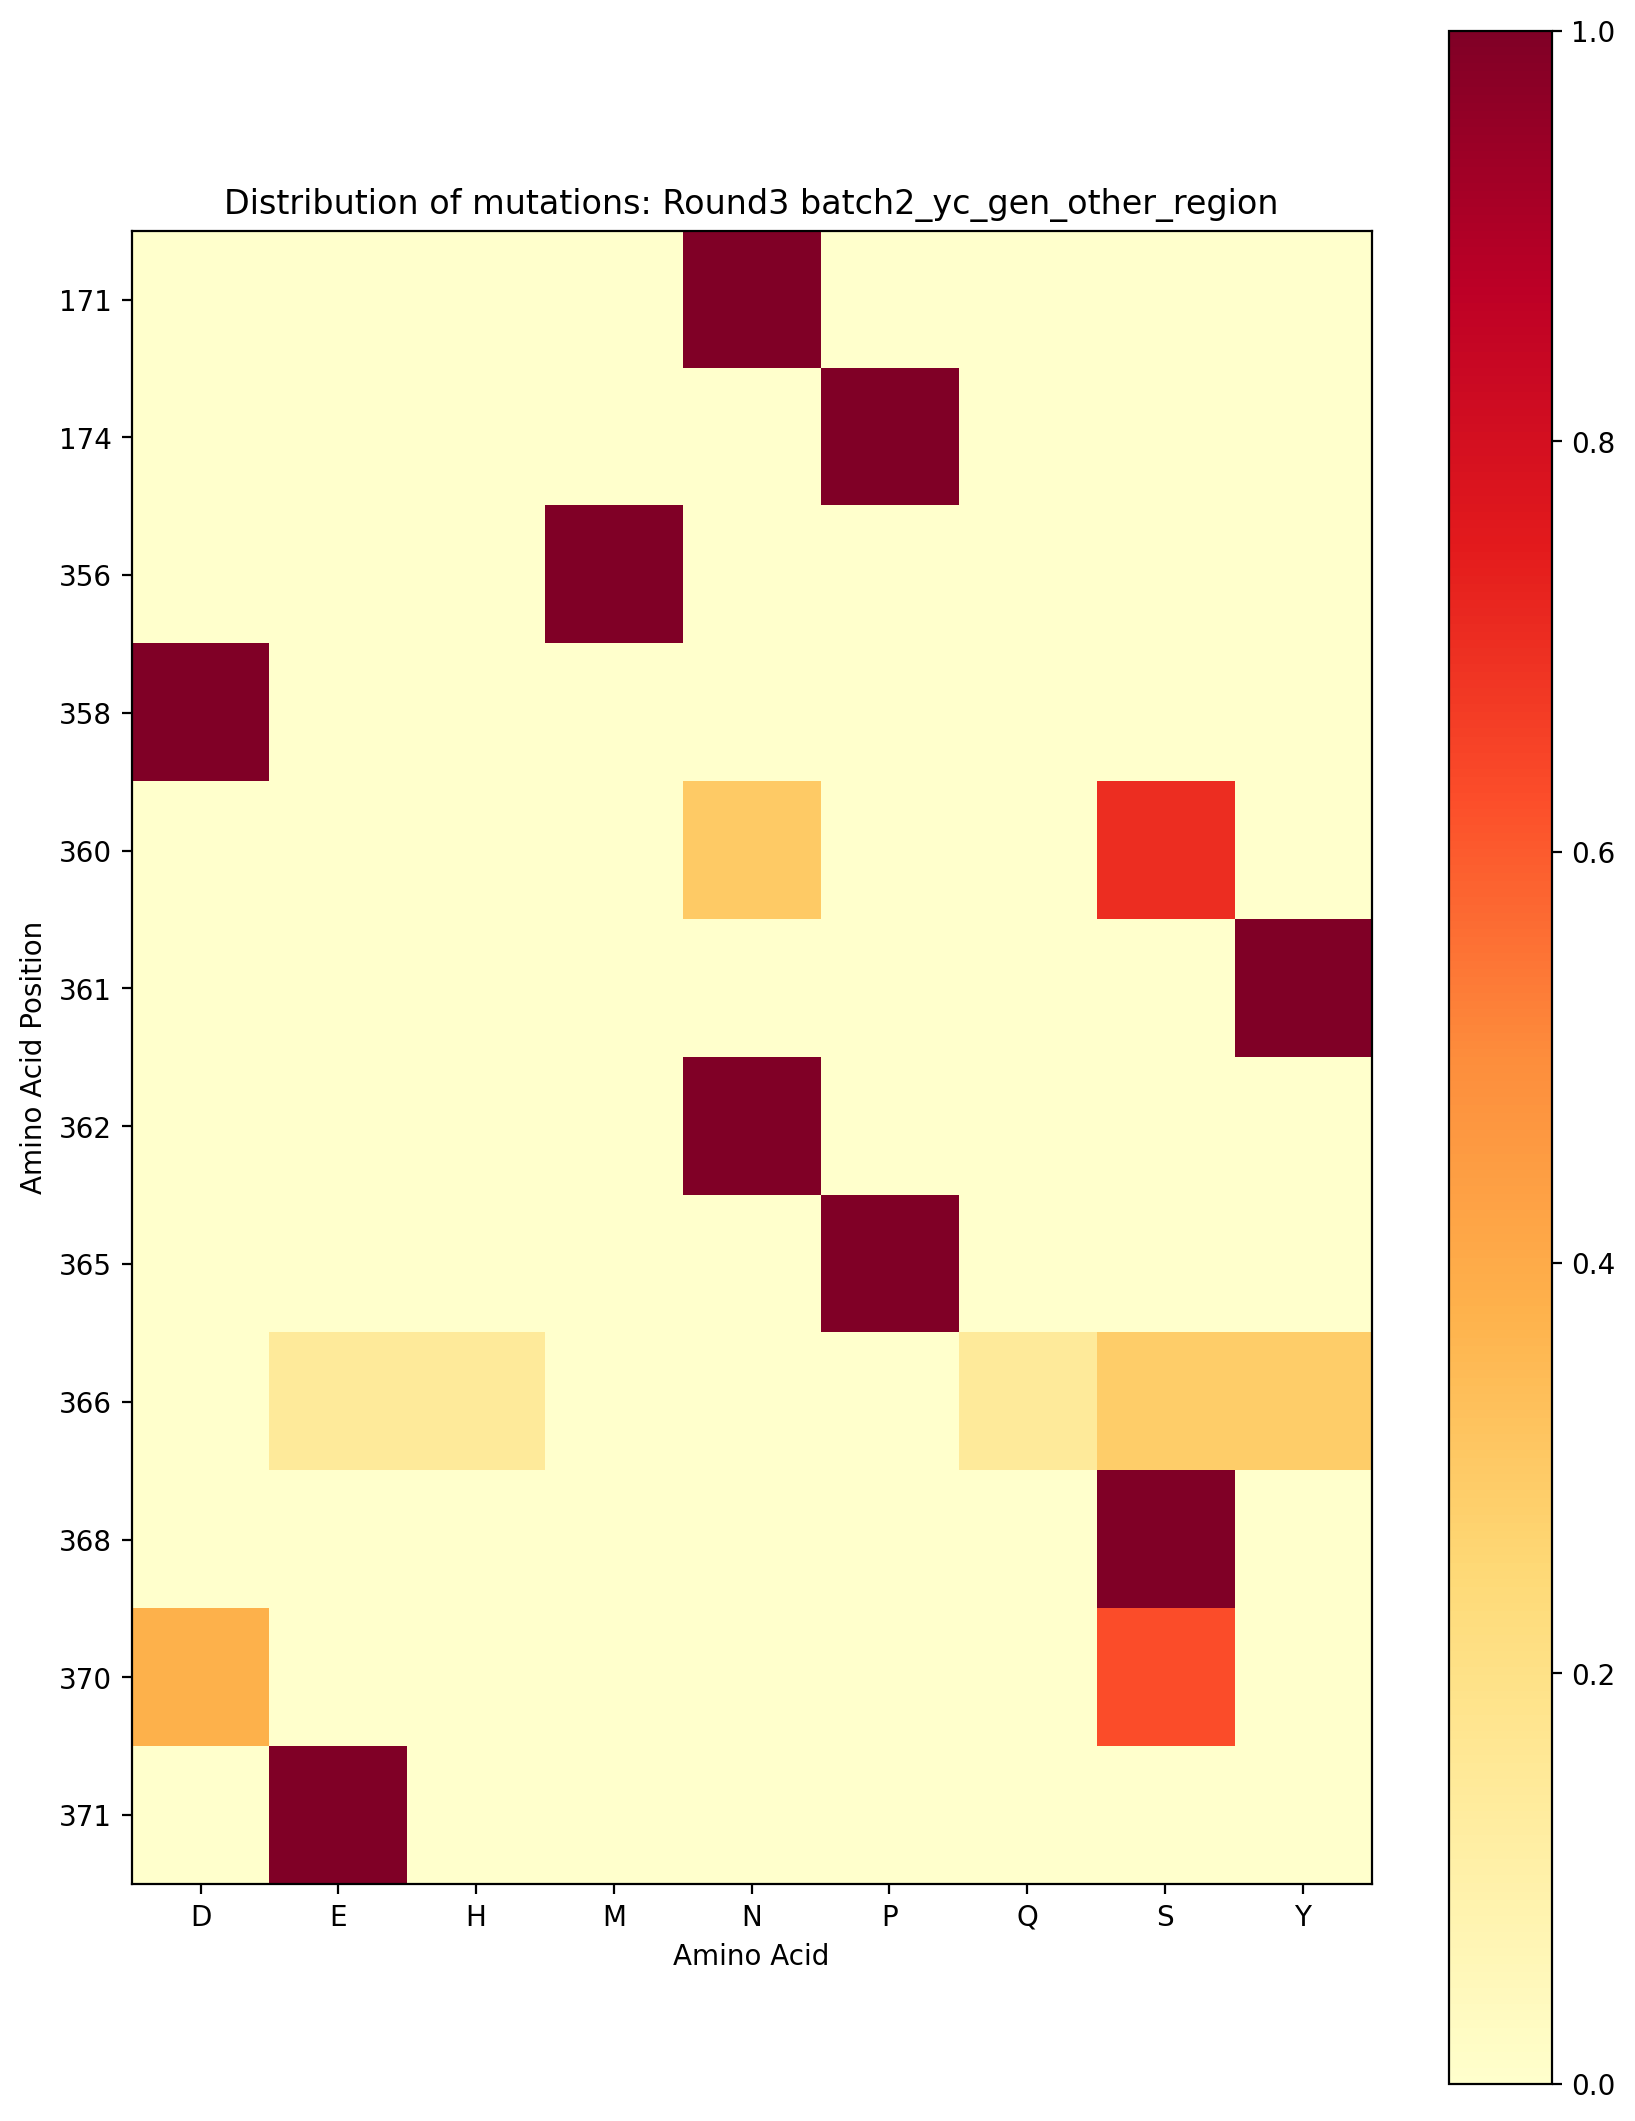

In [35]:
lib_mutation_distribution(data_filtered3, title='Round3 batch2_yc_gen_other_region')

In [36]:
print(data_filtered3.shape)
data_filtered3.to_csv('../data/candidates_ai_round3_batch2_unseen_region_w_ai_region1.csv')

(10, 10)
